# Project 02 — Black-Scholes, Greeks & Derivatives Risk

## Notebook 04 — Implied Volatility & Volatility Smile

This notebook calculates implied volatility from observed market option prices
and examines how implied volatility varies across strike prices.

### Objectives

- Calculate implied volatility by solving the Black-Scholes pricing equation.
- Use a numerical root-finding method to recover implied volatility.
- Compare calculated implied volatility with Yahoo Finance's quoted IV.
- Examine how implied volatility varies across strike prices.
- Plot implied volatility against option moneyness.
- Identify and interpret the volatility smile and volatility skew.
- Examine why the constant-volatility assumption of Black-Scholes does not
  perfectly describe observed option markets.

The analysis builds on the Black-Scholes pricing framework developed in
Notebook 02 and the option-chain and Greeks analysis developed in Notebook 03.

## 1. Load Market Data

Notebook 01 created the cleaned SPY option-chain dataset, which is reused
throughout Project 02.

Notebook 04 uses the same market data and Black-Scholes framework as the
previous notebooks. The observed option mid-price will be used as the market
price from which implied volatility is estimated.

The implied volatility reported by Yahoo Finance is retained as a benchmark
for comparison with our independently calculated value.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from project_02_derivatives_risk_engine.src.black_scholes import black_scholes_price

In [2]:
data_path = Path("../results/csv/spy_option_chain_clean.csv")

options = pd.read_csv(data_path)

print(f"Loaded {len(options)} option contracts")

options.head()

Loaded 256 option contracts


,contract_symbol,option_type,expiration,spot,strike,days_to_expiry,T,moneyness,bid,ask,mid_price,last_price,volume,open_interest,implied_volatility,intrinsic_value,time_value,in_the_money
0,SPY261120C00620000,call,2026-11-20,774.886292,620.0,44,0.120548,0.800117,156.37,160.18,158.275,158.81,6.0,45,0.485814,154.886292,3.388708,True
1,SPY261120C00625000,call,2026-11-20,774.886292,625.0,44,0.120548,0.806570,151.51,155.25,153.380,154.00,2.0,7,0.474035,149.886292,3.493708,True
2,SPY261120C00630000,call,2026-11-20,774.886292,630.0,44,0.120548,0.813023,147.20,150.37,148.785,145.85,2.0,785,0.463384,144.886292,3.898708,True
3,SPY261120C00635000,call,2026-11-20,774.886292,635.0,44,0.120548,0.819475,142.34,144.60,143.470,134.00,2.0,141,0.431982,139.886292,3.583708,True
4,SPY261120C00640000,call,2026-11-20,774.886292,640.0,44,0.120548,0.825928,137.35,139.56,138.455,138.85,1.0,414,0.418005,134.886292,3.568708,True


## 2. Model Assumptions

The implied-volatility calculation uses the same Black-Scholes assumptions as
the previous notebooks.

The model requires the following inputs:

- Underlying price ($S$)
- Strike price ($K$)
- Time to expiration ($T$)
- Risk-free interest rate ($r$)
- Dividend yield ($q$)
- Option market price

Unlike the previous notebooks, volatility ($\sigma$) is no longer specified
as an input.

Instead, implied volatility is the unknown parameter that we solve for.

Given an observed market option price:

$$
P_{market}
$$

we find the volatility $\sigma$ that satisfies:

$$
BS(S,K,T,r,q,\sigma)=P_{market}
$$

The resulting value is the option's implied volatility.

In [3]:
risk_free_rate = 0.04  # 4% annual risk-free rate
dividend_yield = 0.012  # 1.2% annual dividend yield

## 3. What Is Implied Volatility?

Implied volatility is the volatility level that makes a theoretical option
pricing model reproduce the observed market price of an option.

In Black-Scholes, volatility is normally an input:

$$
(S,K,T,r,q,\sigma)
\rightarrow
P_{BS}
$$

For implied volatility, the problem is reversed:

$$
(S,K,T,r,q,P_{market})
\rightarrow
\sigma_{IV}
$$

Therefore, implied volatility is not directly observed in the market.

It is a model-derived quantity obtained by solving the option pricing equation
for volatility.

This makes implied volatility particularly useful for comparing the market's
pricing of risk across different option contracts.

### 3.1 Implied Volatility as an Inverse Pricing Problem

For a call option:

$$
C_{\text{market}} = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)
$$

where

$$
d_1 = \frac{\ln(S/K) + \left(r - q + \frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}
$$

and

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

The market price $C_{\text{market}}$ is known, while $\sigma$ is unknown.

There is generally no closed-form analytical solution for $\sigma$.

Therefore, numerical root-finding methods are used to determine the implied
volatility.

## 4. Numerical Solution

Because implied volatility cannot generally be obtained directly from the
Black-Scholes pricing equation, a numerical root-finding method is required.

We define the pricing error as:

$$
f(\sigma) = \text{BS}(S, K, T, r, q, \sigma) - P_{\text{market}}
$$

The implied volatility is the value of $\sigma$ for which:

$$
f(\sigma) = 0
$$

In this notebook, Brent's method is used as the primary numerical solver.

Brent's method combines the reliability of bracketing methods with the speed
of interpolation-based methods. It requires an interval containing a root and
does not require an initial volatility estimate.

### 4.1 Brent's Method

For a valid option price, we can search for the volatility within a reasonable
interval:

$$
\sigma_{low} < \sigma_{IV} < \sigma_{high}
$$

The solver evaluates the pricing error at the boundaries and searches for the
volatility at which the error changes sign.

For this implementation, the search interval will initially be:

$$
10^{-6} \leq \sigma \leq 5.0
$$

which corresponds approximately to a volatility range from 0% to 500%.

A valid bracket requires:

$$
f(\sigma_{low})f(\sigma_{high}) < 0
$$

Once the root is found, the resulting $\sigma$ is the calculated implied
volatility.

### 4.2 Implied Volatility Function

The implied-volatility function takes the observed market option price and
the remaining Black-Scholes inputs as arguments.

The function then defines the pricing error:

$$f(\sigma) = \text{BS}(S, K, T, r, q, \sigma) - P_{\text{market}}$$

and uses Brent's method to find the value of $\sigma$ for which:

$$f(\sigma) = 0$$

If a valid solution cannot be found within the specified volatility interval,
the function returns `NaN`.

## 5. Calculate Implied Volatility

The implied-volatility solver is now applied to the complete option-chain
dataset.

For each contract, the market mid-price is treated as the observed market
price:

$$
P_{market} = \frac{Bid + Ask}{2}
$$

The solver then finds the volatility that makes the Black-Scholes price equal
to this market price.

The calculated implied volatility will be compared with the implied volatility
reported by Yahoo Finance.

### 5.1 Apply Solver to Option Chain

The solver is applied independently to each option contract.

Contracts for which a valid implied volatility cannot be obtained will be
assigned `NaN`. These observations can then be examined separately rather
than forcing an unreliable volatility estimate.

In [ ]:
from project_02_derivatives_risk_engine.src.implied_volatility import calculate_implied_volatility

In [5]:
options["calculated_iv"] = options.apply(
    lambda row: calculate_implied_volatility(
        market_price=row["mid_price"],
        S=row["spot"],
        K=row["strike"],
        T=row["T"],
        r=risk_free_rate,
        q=dividend_yield,
        option_type=row["option_type"]
    ),
    axis=1
)

In [6]:
options["iv_difference"] = (
    options["calculated_iv"]
    - options["implied_volatility"]
)

In [7]:
options[
    [
        "contract_symbol",
        "option_type",
        "strike",
        "mid_price",
        "implied_volatility",
        "calculated_iv",
        "iv_difference"
    ]
].head(10)

,contract_symbol,option_type,strike,mid_price,implied_volatility,calculated_iv,iv_difference
0,SPY261120C00620000,call,620.0,158.275,0.485814,0.095763,-0.390051
1,SPY261120C00625000,call,625.0,153.380,0.474035,0.096402,-0.377632
2,SPY261120C00630000,call,630.0,148.785,0.463384,0.101029,-0.362355
3,SPY261120C00635000,call,635.0,143.470,0.431982,0.096065,-0.335917
4,SPY261120C00640000,call,640.0,138.455,0.418005,0.095113,-0.322892
5,SPY261120C00645000,call,645.0,133.670,0.426886,0.097169,-0.329717
6,SPY261120C00650000,call,650.0,128.590,0.394781,0.095384,-0.299397
7,SPY261120C00655000,call,655.0,123.715,0.385321,0.096254,-0.289068
8,SPY261120C00660000,call,660.0,119.465,0.400702,0.105061,-0.295640
9,SPY261120C00665000,call,665.0,113.895,0.362555,0.097069,-0.265486


In [8]:
print(f"Total contracts: {len(options)}")
print(f"Successful IV calculations: {options['calculated_iv'].notna().sum()}")
print(f"Failed IV calculations: {options['calculated_iv'].isna().sum()}")

Total contracts: 256
Successful IV calculations: 147
Failed IV calculations: 109


### 5.2 Compare with Yahoo IV

The calculated implied volatility can be compared with the implied volatility
reported by Yahoo Finance.

Both values represent the volatility required to explain the option price under
a Black-Scholes framework, but differences can arise from differences in the
market price used, model assumptions, and numerical implementation.

The comparison provides a useful check of whether the independently calculated
implied volatilities are broadly consistent with the market data.

In [9]:
iv_comparison = options[
    [
        "contract_symbol",
        "option_type",
        "strike",
        "mid_price",
        "implied_volatility",
        "calculated_iv",
        "iv_difference"
    ]
].dropna(subset=["calculated_iv", "implied_volatility"])

iv_comparison.head(10)

,contract_symbol,option_type,strike,mid_price,implied_volatility,calculated_iv,iv_difference
0,SPY261120C00620000,call,620.0,158.275,0.485814,0.095763,-0.390051
1,SPY261120C00625000,call,625.0,153.380,0.474035,0.096402,-0.377632
2,SPY261120C00630000,call,630.0,148.785,0.463384,0.101029,-0.362355
3,SPY261120C00635000,call,635.0,143.470,0.431982,0.096065,-0.335917
4,SPY261120C00640000,call,640.0,138.455,0.418005,0.095113,-0.322892
5,SPY261120C00645000,call,645.0,133.670,0.426886,0.097169,-0.329717
6,SPY261120C00650000,call,650.0,128.590,0.394781,0.095384,-0.299397
7,SPY261120C00655000,call,655.0,123.715,0.385321,0.096254,-0.289068
8,SPY261120C00660000,call,660.0,119.465,0.400702,0.105061,-0.295640
9,SPY261120C00665000,call,665.0,113.895,0.362555,0.097069,-0.265486


In [10]:
print(f"Contracts compared: {len(iv_comparison)}")
print(f"Mean IV difference: {iv_comparison['iv_difference'].mean():.6f}")
print(f"Mean absolute IV difference: {iv_comparison['iv_difference'].abs().mean():.6f}")
print(f"Maximum absolute IV difference: {iv_comparison['iv_difference'].abs().max():.6f}")

Contracts compared: 147
Mean IV difference: 0.084630
Mean absolute IV difference: 0.233672
Maximum absolute IV difference: 1.263337


### 5.3 IV Calculation Errors

The difference between the independently calculated implied volatility and the
Yahoo Finance implied volatility can be examined using the IV calculation error.

The absolute difference is defined as:

$$
\text{IV Error} = |\sigma_{\text{calculated}} - \sigma_{\text{Yahoo}}|
$$

A small difference indicates that the two implied-volatility estimates are
closely aligned.

Larger differences may occur because the two calculations use different option
prices, market inputs, numerical procedures, or data snapshots.

The comparison is therefore treated as a consistency check rather than an exact
replication of Yahoo Finance's methodology.

In [11]:
options["iv_abs_error"] = options["iv_difference"].abs()

iv_errors = options[
    [
        "contract_symbol",
        "option_type",
        "strike",
        "mid_price",
        "implied_volatility",
        "calculated_iv",
        "iv_difference",
        "iv_abs_error"
    ]
].dropna(subset=["calculated_iv"])

iv_errors.sort_values(
    "iv_abs_error",
    ascending=False
).head(10)

,contract_symbol,option_type,strike,mid_price,implied_volatility,calculated_iv,iv_difference,iv_abs_error
128,SPY261120C00925000,call,925.0,0.015,0.168954,1.432291,1.263337,1.263337
127,SPY261120C00920000,call,920.0,0.015,0.164071,1.387329,1.223258,1.223258
126,SPY261120C00915000,call,915.0,0.015,0.159188,1.342122,1.182934,1.182934
125,SPY261120C00910000,call,910.0,0.015,0.154305,1.296668,1.142362,1.142362
124,SPY261120C00905000,call,905.0,0.025,0.155282,1.257310,1.102028,1.102028
123,SPY261120C00900000,call,900.0,0.025,0.150399,1.211352,1.060953,1.060953
122,SPY261120C00895000,call,895.0,0.030,0.149423,1.167491,1.018069,1.018069
121,SPY261120C00890000,call,890.0,0.035,0.144540,1.123047,0.978508,0.978508
120,SPY261120C00885000,call,885.0,0.045,0.142098,1.079703,0.937605,0.937605
119,SPY261120C00880000,call,880.0,0.045,0.136727,1.032703,0.895976,0.895976


## 6. Volatility Smile

Implied volatility is not constant across option strike prices.

If Black-Scholes assumptions were perfectly consistent with observed market
prices, options with the same underlying, expiration, and market conditions
would generally imply similar volatility regardless of strike.

In practice, implied volatility varies across strikes. Plotting implied
volatility against strike price reveals the market's volatility smile or
volatility skew.

This section examines the calculated implied volatility across the option chain
and compares the pattern between calls and puts.

### 6.1 Prepare IV Data

Only contracts for which implied volatility was successfully calculated are
included in the volatility analysis.

Moneyness is used as the horizontal axis because it provides a more meaningful
comparison across different strike prices:

$$
\text{Moneyness} = \frac{K}{S}
$$

A value below 1 indicates an out-of-the-money call or an in-the-money put,
while a value above 1 indicates an in-the-money call or an out-of-the-money
put.

In [12]:
iv_data = options.dropna(subset=["calculated_iv"]).copy()

iv_data["moneyness"] = (
    iv_data["strike"] / iv_data["spot"]
)

calls = iv_data[
    iv_data["option_type"].str.lower() == "call"
].sort_values("moneyness")

puts = iv_data[
    iv_data["option_type"].str.lower() == "put"
].sort_values("moneyness")

print(f"Valid IV observations: {len(iv_data)}")
print(f"Calls: {len(calls)}")
print(f"Puts: {len(puts)}")

Valid IV observations: 147
Calls: 129
Puts: 18


### 6.2 Volatility Smile — Calls and Puts

The implied volatility of each option is plotted against its moneyness.

A flat relationship would be consistent with the constant-volatility assumption
of the basic Black-Scholes model.

A curved or sloped relationship indicates that the market assigns different
implied volatility levels to options at different strikes.

Calls and puts are plotted separately to make the structure of the volatility
smile or skew easier to observe.

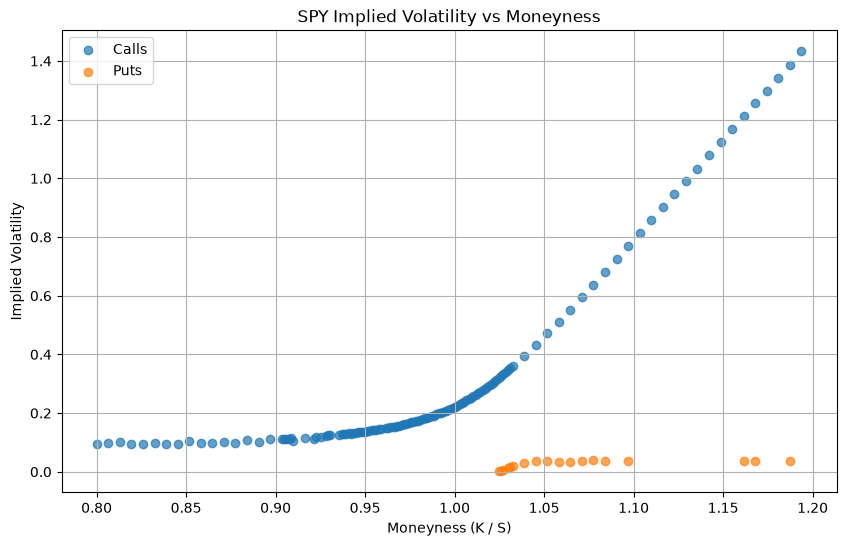

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    calls["moneyness"],
    calls["calculated_iv"],
    label="Calls",
    alpha=0.7
)

plt.scatter(
    puts["moneyness"],
    puts["calculated_iv"],
    label="Puts",
    alpha=0.7
)

plt.xlabel("Moneyness (K / S)")
plt.ylabel("Implied Volatility")
plt.title("SPY Implied Volatility vs Moneyness")
plt.legend()
plt.grid(True)

plt.show()

### 6.3 Interpretation of the Volatility Structure

The calculated implied-volatility plot does not produce a clean, symmetric
volatility smile across the entire strike range.

The call observations show a relatively stable implied volatility around the
at-the-money region, followed by a sharp increase for higher moneyness.

This behavior should not be interpreted as a genuine 100%+ market volatility
expectation. Deep in-the-money options can have very low sensitivity to
volatility because their prices are dominated by intrinsic value. When implied
volatility is recovered by numerically inverting the Black-Scholes equation,
small differences in the observed option price can therefore produce very large
changes in the calculated implied volatility.

The extreme implied-volatility observations are therefore an example of
numerical instability in the inverse pricing problem.

The region around the at-the-money strikes provides a more meaningful view of
the volatility structure. In this region, option prices contain more
time-value information and implied volatility is less sensitive to small
pricing differences.

This illustrates an important practical consideration in derivatives risk
systems: implied volatility should not be interpreted without considering
option liquidity, moneyness, time value, and numerical stability.

## 7. Volatility Skew

Volatility skew describes the tendency for implied volatility to vary
systematically with option strike price.

In equity markets, implied volatility is often higher for out-of-the-money
puts than for comparable at-the-money options. This produces a downward-sloping
relationship when implied volatility is viewed against strike price or
moneyness.

The skew reflects the market's demand for downside protection and the
distribution of risks perceived by market participants.

The volatility structure observed in the option chain therefore contains
information beyond the single volatility assumption used by the basic
Black-Scholes model.

### 7.1 Why Equity Options Exhibit Skew

Equity index and large-cap equity options commonly exhibit a downside
volatility skew.

Several factors contribute to this structure:

- Investors frequently purchase out-of-the-money puts as downside protection.
- Demand for downside protection increases the prices of these options.
- Higher option prices translate into higher implied volatilities.
- Equity returns tend to exhibit negative skewness and volatility tends to
  increase during market declines.
- Market participants therefore do not generally view future volatility as
  constant across all market states.

As a result, the market-implied volatility distribution differs from the
constant-volatility assumption of the basic Black-Scholes model.

### 7.2 Interpreting the Observed SPY Skew

The option chain used in this analysis contains substantially more valid call
observations than put observations. Therefore, the observed relationship should
not be interpreted as a complete estimate of the SPY volatility skew.

The calculated call implied volatilities remain relatively stable around the
lower-moneyness region but increase sharply at higher moneyness. As discussed
earlier, the extreme values are likely influenced by the numerical sensitivity
of implied-volatility inversion for deep in-the-money options.

The limited number of valid put observations also makes it difficult to
establish a robust downside skew from this particular sample.

Nevertheless, the analysis demonstrates an important property of real option
markets: implied volatility varies across strikes rather than remaining
constant. This is one reason practitioners use an implied-volatility surface
rather than a single volatility input when pricing and managing more complex
derivatives portfolios.

## 8. Black-Scholes vs Market Reality

The Black-Scholes model assumes a constant volatility across all option strikes
and maturities.

The implied-volatility analysis demonstrates that this assumption does not
fully describe observed option markets.

Instead, market prices imply different volatility levels across strikes. The
resulting volatility smile or skew reflects information about the market's
expectations, risk preferences, and demand for particular option exposures.

Several practical limitations of the basic Black-Scholes framework are
illustrated by this analysis:

- Volatility is not constant across strikes.
- Volatility is not necessarily constant through time.
- Option prices can be affected by liquidity and bid-ask spreads.
- Deep in-the-money and deep out-of-the-money options can produce numerical
  instability when implied volatility is recovered.
- Market prices may differ from theoretical prices because of supply, demand,
  transaction costs, and other market frictions.
- A single volatility parameter is therefore insufficient to represent the
  entire observed option market.

For practical derivatives valuation and risk management, volatility is commonly
represented as a function of strike and maturity rather than as a single
constant.

The Black-Scholes model therefore remains useful as a foundational pricing
framework, while implied-volatility analysis provides a bridge between the
theoretical model and observed market prices.

## 9. Key Findings

This notebook demonstrated how implied volatility can be recovered from
observed option prices and used to examine the volatility structure of the
SPY option chain.

The main findings are:

- Implied volatility can be calculated by numerically inverting the
  Black-Scholes pricing equation.
- Brent's root-finding method provides a robust approach for solving the
  implied-volatility equation when a valid pricing root exists.
- Of the 256 option contracts in the dataset, 147 produced valid implied
  volatility estimates.
- The independently calculated implied volatilities showed meaningful
  differences from the Yahoo Finance values, demonstrating that implied
  volatility depends on the precise market inputs and methodology used.
- Implied volatility varies across strike prices rather than remaining
  constant.
- Extreme implied-volatility values can occur for deep in-the-money options
  because their prices are dominated by intrinsic value and have low
  sensitivity to volatility.
- The observed option chain does not provide sufficient valid put observations
  to establish a robust estimate of the complete SPY volatility skew.
- The results demonstrate why practical derivatives models cannot rely on a
  single constant volatility assumption.
- From a risk-management perspective, implied volatility should be evaluated
  together with moneyness, liquidity, time value, and numerical stability.

Overall, the analysis connects the theoretical Black-Scholes framework with
observed market option prices and demonstrates the importance of implied
volatility in practical derivatives valuation and risk management.